<a href="https://colab.research.google.com/github/Dipu1764/ML-3-/blob/DATA/ML_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data loading




In [ ]:
df = pd.read_csv("/content/Fruit Classification (1).csv")
df.head()

,Unnamed: 0,Color,Size,Fruit
0,0,Red,Large,Apple
1,1,Green,Large,Banana
2,2,Red,Medium,Banana
3,3,Red,Large,Apple
4,4,Red,Large,Apple


In [ ]:
df.shape

(100, 4)

In [ ]:
df.describe()

,Unnamed: 0
count,100.000000
mean,49.500000
std,29.011492
min,0.000000
25%,24.750000
50%,49.500000
75%,74.250000
max,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  100 non-null    int64 
 1   Color       100 non-null    object
 2   Size        100 non-null    object
 3   Fruit       100 non-null    object
dtypes: int64(1), object(3)
memory usage: 3.3+ KB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Color,0
Size,0
Fruit,0


In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df

,Color,Size,Fruit
0,Red,Large,Apple
1,Green,Large,Banana
2,Red,Medium,Banana
3,Red,Large,Apple
4,Red,Large,Apple
...,...,...,...
95,Green,Large,Apple
96,Green,Medium,Apple
97,Green,Large,Apple
98,Yellow,Small,Banana


In [ ]:
df['Color'] = df['Color'].map({'Green': 0, 'Yellow': 1, 'Red': 2, 'Orange': 3, 'Purple': 4})
df['Size'] = df['Size'].map({'Small': 0, 'Medium': 1, 'Large': 2})
df['Fruit'] = df['Fruit'].map({'Apple': 0, 'Banana': 1,})

In [ ]:
X = df[['Color', 'Size']]
y = df['Fruit']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
prediction = model.predict([[2, 0]])
prediction = 'Apple' if prediction == 0 else 'Banana'
print(prediction)

Apple


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score

test_predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, test_predictions) * 100)

Accuracy: 63.33333333333333


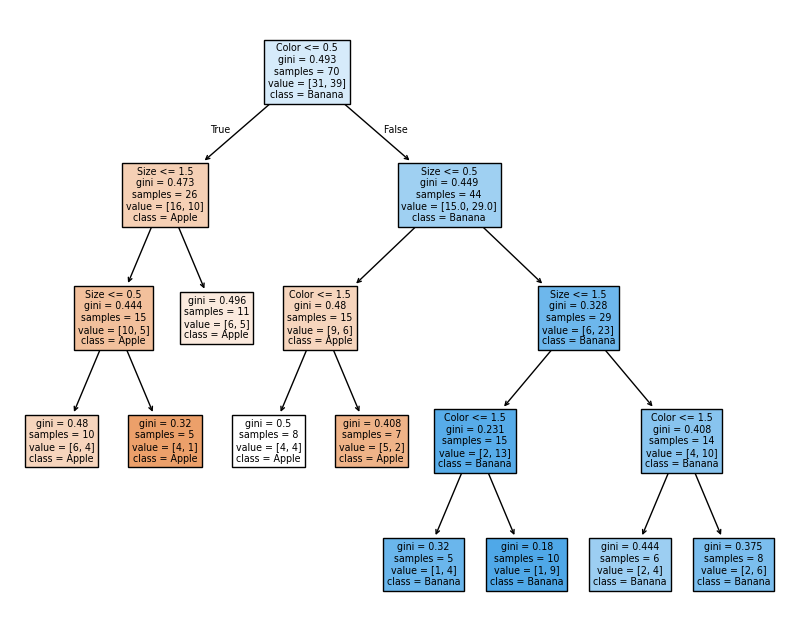

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

# Plot the decision tree
plt.figure(figsize=(10, 8))
plot_tree(model, filled=True, feature_names=['Color', 'Size'], class_names=['Apple', 'Banana'])
plt.show()

# **unsupervised learning**

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

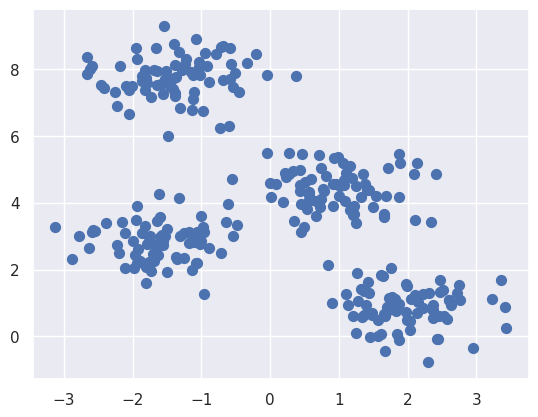

In [2]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50)

In [4]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

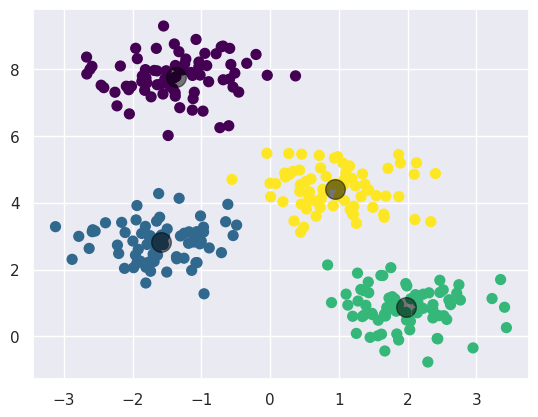

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

In [7]:
kmeans.cluster_centers_

array([[-1.37324398,  7.75368871],
       [-1.58438467,  2.83081263],
       [ 1.98258281,  0.86771314],
       [ 0.94973532,  4.41906906]])